# Preprocessing Dataset Smart Agriculture untuk Dashboard IoT

## Pendahuluan
Notebook ini bertujuan untuk melakukan preprocessing dataset 'Semantic-Aware IoT Dataset for Smart Agriculture' guna mempersiapkan data untuk penelitian "Rancang Bangun Dashboard untuk Usaha Tani Kecil Berbasis IoT". Langkah-langkah preprocessing meliputi impor library, pemuatan data, pembersihan data, normalisasi, pemilihan fitur, visualisasi awal, dan penyimpanan hasil akhir.

## 1. Import Library

In [6]:
# Mengimpor library yang diperlukan untuk analisis dan preprocessing data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
import warnings

# Mengabaikan peringatan untuk tampilan output yang lebih bersih
warnings.filterwarnings('ignore')

print("Libraries berhasil diimpor.")

Libraries berhasil diimpor.


## 2. Load Dataset

In [7]:
# Menentukan path file dataset dari Google Drive
# Pastikan Google Drive sudah di-mount sebelumnya.
file_path = '/content/drive/MyDrive/dataset/Agriculture_dataset_with_metadata.csv'

try:
    # Membaca file CSV ke dalam DataFrame pandas
    df = pd.read_csv(file_path)
    print("Dataset berhasil dimuat.")

    # Menampilkan bentuk (shape) dataset (jumlah baris, jumlah kolom)
    print(f"\nShape dataset: {df.shape}")

    # Menampilkan informasi dasar tentang dataset (tipe data, non-null count, dll.)
    print("\nInformasi Dataset (df.info()):")
    df.info()

    # Menampilkan ringkasan missing values dalam persentase
    print("\nRingkasan Missing Values (%):")
    missing_values_summary = df.isnull().sum() * 100 / len(df)
    print(missing_values_summary[missing_values_summary > 0].sort_values(ascending=False))

    # Menampilkan 5 baris pertama dari dataset
    print("\n5 Baris Pertama Dataset (df.head()):")
    display(df.head())

except FileNotFoundError:
    print(f"Error: File tidak ditemukan di path: {file_path}. Pastikan path benar dan Drive sudah di-mount.")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat dataset: {e}")

Dataset berhasil dimuat.

Shape dataset: (60000, 24)

Informasi Dataset (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Zone_ID              60000 non-null  object 
 1   Image_Source_ID      60000 non-null  object 
 2   Image_Type           60000 non-null  object 
 3   NDVI                 29892 non-null  float64
 4   NDRE                 29892 non-null  float64
 5   RGB_Damage_Score     30108 non-null  float64
 6   UAV_Timestamp        60000 non-null  object 
 7   N                    60000 non-null  int64  
 8   P                    60000 non-null  int64  
 9   K                    60000 non-null  int64  
 10  Moisture             60000 non-null  float64
 11  pH                   60000 non-null  float64
 12  Temperature          60000 non-null  float64
 13  Humidity             60000 non-null  float64
 14  N

,Zone_ID,Image_Source_ID,Image_Type,NDVI,NDRE,RGB_Damage_Score,UAV_Timestamp,N,P,K,...,NDI_Label,PDI_Label,Semantic_Tag,Action_Suggested,Energy_Consumed_mAh,Latency_ms,Current_Node,Migrated_To,Migration_Required,Migration_Timestamp
0,Z8,IMG_Z8_202504010600.jpg,Multispectral,0.52,0.52,NaN,4/1/2025 6:00,43,33,94,...,Medium,Medium,"P-deficiency, K-deficiency",Apply Pesticide,3.90,35.90,Cloud-Node-1,Cloud-Node-1,No,NaN
1,Z1,IMG_Z1_202504010605.jpg,Multispectral,0.47,0.12,NaN,4/1/2025 6:05,65,27,39,...,High,High,"N-deficiency, Healthy",Monitor,1.18,34.10,Cloud-Node-2,Cloud-Node-2,No,NaN
2,Z10,IMG_Z10_202504010610.jpg,Multispectral,0.54,0.45,NaN,4/1/2025 6:10,29,40,65,...,Low,Low,"P-deficiency, K-deficiency",Apply Fertilizer,2.99,33.55,Edge-Node-B,Edge-Node-B,No,NaN
3,Z5,IMG_Z5_202504010615.jpg,RGB,NaN,NaN,0.31,4/1/2025 6:15,47,37,70,...,Medium,Low,"K-deficiency, K-deficiency",Apply Fertilizer,8.86,34.74,Edge-Node-B,Edge-Node-B,No,NaN
4,Z4,IMG_Z4_202504010620.jpg,Multispectral,0.69,0.54,NaN,4/1/2025 6:20,67,28,36,...,Medium,Low,"K-deficiency, N-deficiency",Apply Fertilizer,1.19,34.78,Edge-Node-A,Cloud-Node-2,Yes,4/1/2025 6:20


## 3. Data Cleaning

In [8]:
# Membuat salinan DataFrame untuk proses cleaning agar data asli tetap utuh
df_cleaned = df.copy()
print("DataFrame awal untuk cleaning berhasil disalin.")

# --- Identifikasi dan Penanganan Duplikat ---
print("\n--- Penanganan Duplikat ---")
initial_rows = df_cleaned.shape[0]
df_cleaned.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df_cleaned.shape[0]

if duplicates_removed > 0:
    print(f"Jumlah baris duplikat yang dihapus: {duplicates_removed}")
    print(f"Shape dataset setelah menghapus duplikat: {df_cleaned.shape}")
else:
    print("Tidak ada baris duplikat yang ditemukan.")

# --- Identifikasi dan Penanganan Missing Values ---
print("\n--- Penanganan Missing Values ---")

# Memisahkan kolom numerik dan kategorikal
numerical_cols = df_cleaned.select_dtypes(include=np.number).columns
categorical_cols = df_cleaned.select_dtypes(include='object').columns

# Menangani missing values pada kolom numerik dengan median
print("Mengisi missing values pada kolom numerik dengan median...")
for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"  - Kolom '{col}' diisi dengan median: {median_val}")

# Menangani missing values pada kolom kategorikal dengan modus
print("Mengisi missing values pada kolom kategorikal dengan modus...")
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0] # mode() bisa mengembalikan lebih dari satu, ambil yang pertama
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"  - Kolom '{col}' diisi dengan modus: {mode_val}")

# Memastikan tidak ada missing value setelah penanganan
missing_after_cleaning = df_cleaned.isnull().sum().sum()
if missing_after_cleaning == 0:
    print("\nSemua missing values berhasil ditangani. Dataset bersih dari missing values.")
else:
    print(f"\nMasih ada {missing_after_cleaning} missing values setelah penanganan.")
    print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

# --- Penanganan Outlier Sederhana (menggunakan IQR untuk kolom numerik) ---
print("\n--- Penanganan Outlier Sederhana (dengan IQR) ---")
initial_rows_outlier = df_cleaned.shape[0]
num_outliers_treated = 0

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mengidentifikasi outlier
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]

    if not outliers.empty:
        # Mengganti outlier dengan batas terdekat (clipping)
        df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound, df_cleaned[col])
        df_cleaned[col] = np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
        num_outliers_treated += len(outliers)
        print(f"  - Outlier pada kolom '{col}' ditangani ({len(outliers)} nilai di-clipping).")

if num_outliers_treated > 0:
    print(f"Total outlier yang ditangani: {num_outliers_treated} nilai.")
else:
    print("Tidak ada outlier signifikan yang ditangani dengan metode IQR sederhana.")

print(f"Shape dataset setelah penanganan outlier: {df_cleaned.shape}")

# --- Tampilkan Perbandingan Sebelum vs Sesudah Cleaning ---
print("\n--- Perbandingan Sebelum vs Sesudah Cleaning ---")
print("\nRingkasan Missing Values (%) - Sebelum Cleaning:")
missing_values_summary_before = df.isnull().sum() * 100 / len(df)
print(missing_values_summary_before[missing_values_summary_before > 0].sort_values(ascending=False))

print("\nRingkasan Missing Values (%) - Sesudah Cleaning:")
missing_values_summary_after = df_cleaned.isnull().sum() * 100 / len(df_cleaned)
print(missing_values_summary_after[missing_values_summary_after > 0].sort_values(ascending=False))

print(f"\nJumlah baris sebelum cleaning: {df.shape[0]}")
print(f"Jumlah baris setelah cleaning: {df_cleaned.shape[0]}")

print("\n5 Baris Pertama Dataset Setelah Cleaning (df_cleaned.head()):")
display(df_cleaned.head())

DataFrame awal untuk cleaning berhasil disalin.

--- Penanganan Duplikat ---
Tidak ada baris duplikat yang ditemukan.

--- Penanganan Missing Values ---
Mengisi missing values pada kolom numerik dengan median...
  - Kolom 'NDVI' diisi dengan median: 0.58
  - Kolom 'NDRE' diisi dengan median: 0.35
  - Kolom 'RGB_Damage_Score' diisi dengan median: 0.5
Mengisi missing values pada kolom kategorikal dengan modus...
  - Kolom 'Migration_Timestamp' diisi dengan modus: 10/1/2025 0:05

Semua missing values berhasil ditangani. Dataset bersih dari missing values.

--- Penanganan Outlier Sederhana (dengan IQR) ---
  - Outlier pada kolom 'NDVI' ditangani (29420 nilai di-clipping).
  - Outlier pada kolom 'NDRE' ditangani (29317 nilai di-clipping).
  - Outlier pada kolom 'RGB_Damage_Score' ditangani (29800 nilai di-clipping).
Total outlier yang ditangani: 88537 nilai.
Shape dataset setelah penanganan outlier: (60000, 24)

--- Perbandingan Sebelum vs Sesudah Cleaning ---

Ringkasan Missing Values (%) 

,Zone_ID,Image_Source_ID,Image_Type,NDVI,NDRE,RGB_Damage_Score,UAV_Timestamp,N,P,K,...,NDI_Label,PDI_Label,Semantic_Tag,Action_Suggested,Energy_Consumed_mAh,Latency_ms,Current_Node,Migrated_To,Migration_Required,Migration_Timestamp
0,Z8,IMG_Z8_202504010600.jpg,Multispectral,0.58,0.35,0.5,4/1/2025 6:00,43,33,94,...,Medium,Medium,"P-deficiency, K-deficiency",Apply Pesticide,3.90,35.90,Cloud-Node-1,Cloud-Node-1,No,10/1/2025 0:05
1,Z1,IMG_Z1_202504010605.jpg,Multispectral,0.58,0.35,0.5,4/1/2025 6:05,65,27,39,...,High,High,"N-deficiency, Healthy",Monitor,1.18,34.10,Cloud-Node-2,Cloud-Node-2,No,10/1/2025 0:05
2,Z10,IMG_Z10_202504010610.jpg,Multispectral,0.58,0.35,0.5,4/1/2025 6:10,29,40,65,...,Low,Low,"P-deficiency, K-deficiency",Apply Fertilizer,2.99,33.55,Edge-Node-B,Edge-Node-B,No,10/1/2025 0:05
3,Z5,IMG_Z5_202504010615.jpg,RGB,0.58,0.35,0.5,4/1/2025 6:15,47,37,70,...,Medium,Low,"K-deficiency, K-deficiency",Apply Fertilizer,8.86,34.74,Edge-Node-B,Edge-Node-B,No,10/1/2025 0:05
4,Z4,IMG_Z4_202504010620.jpg,Multispectral,0.58,0.35,0.5,4/1/2025 6:20,67,28,36,...,Medium,Low,"K-deficiency, N-deficiency",Apply Fertilizer,1.19,34.78,Edge-Node-A,Cloud-Node-2,Yes,4/1/2025 6:20


## 4. Normalisasi Data

In [9]:
# Membuat salinan DataFrame untuk normalisasi
df_normalized = df_cleaned.copy()

print("\n--- Normalisasi Data ---")

# Mengidentifikasi kolom numerik otomatis dari df_cleaned
numerical_cols_for_normalization = df_normalized.select_dtypes(include=np.number).columns.tolist()

if 'UAV_Timestamp' in numerical_cols_for_normalization: # UAV_Timestamp was object, but just in case it's numeric after some conversion
    numerical_cols_for_normalization.remove('UAV_Timestamp') # Exclude timestamp if it's numeric and shouldn't be scaled

print(f"Kolom numerik yang akan dinormalisasi: {numerical_cols_for_normalization}")

# --- Min-Max Scaling ---
print("\nMenerapkan Min-Max Scaling...")
scaler_minmax = MinMaxScaler()
df_minmax_scaled = df_normalized.copy()
df_minmax_scaled[numerical_cols_for_normalization] = scaler_minmax.fit_transform(df_minmax_scaled[numerical_cols_for_normalization])

print("Dataset setelah Min-Max Scaling (5 baris pertama):")
display(df_minmax_scaled.head())

print("\nPenjelasan Min-Max Scaling:")
print("   - Min-Max Scaling mengubah nilai fitur ke dalam rentang tertentu (biasanya 0 hingga 1).")
print("   - Cocok digunakan ketika distribusi data tidak Gaussian atau ketika algoritma yang digunakan tidak mengasumsikan distribusi normal (misalnya, Neural Networks, K-Nearest Neighbors).")
print("   - Sensitif terhadap outlier. Jika ada outlier, rentang akan menjadi sangat besar dan sebagian besar data akan terkumpul di satu area kecil.")

# --- Standardization (Z-score Normalization) ---
print("\nMenerapkan Standardization (Z-score Normalization)...")
scaler_standard = StandardScaler()
df_standard_scaled = df_normalized.copy()
df_standard_scaled[numerical_cols_for_normalization] = scaler_standard.fit_transform(df_standard_scaled[numerical_cols_for_normalization])

print("Dataset setelah Standardization (5 baris pertama):")
display(df_standard_scaled.head())

print("\nPenjelasan Standardization:")
print("   - Standardization (Z-score Normalization) mengubah data sehingga memiliki mean 0 dan standard deviasi 1.")
print("   - Cocok digunakan ketika distribusi data mendekati Gaussian (normal) atau ketika algoritma yang digunakan mengasumsikan distribusi normal (misalnya, Regresi Linear, Regresi Logistik, Support Vector Machines).")
print("   - Kurang sensitif terhadap outlier dibandingkan Min-Max Scaling karena tidak membatasi rentang data.")

# Menyimpan dataset hasil normalisasi (pilih salah satu atau simpan keduanya)
# Untuk keperluan selanjutnya, kita akan menggunakan Min-Max Scaled dataset.
# Jika ada kebutuhan khusus, bisa diganti ke df_standard_scaled
df_normalized_output = df_minmax_scaled.copy()
print("\nDataset akhir untuk tahap normalisasi disimpan sebagai df_normalized_output (menggunakan Min-Max Scaling).")


--- Normalisasi Data ---
Kolom numerik yang akan dinormalisasi: ['NDVI', 'NDRE', 'RGB_Damage_Score', 'N', 'P', 'K', 'Moisture', 'pH', 'Temperature', 'Humidity', 'Energy_Consumed_mAh', 'Latency_ms']

Menerapkan Min-Max Scaling...
Dataset setelah Min-Max Scaling (5 baris pertama):


,Zone_ID,Image_Source_ID,Image_Type,NDVI,NDRE,RGB_Damage_Score,UAV_Timestamp,N,P,K,...,NDI_Label,PDI_Label,Semantic_Tag,Action_Suggested,Energy_Consumed_mAh,Latency_ms,Current_Node,Migrated_To,Migration_Required,Migration_Timestamp
0,Z8,IMG_Z8_202504010600.jpg,Multispectral,0.0,0.0,0.0,4/1/2025 6:00,0.474576,0.717949,1.000000,...,Medium,Medium,"P-deficiency, K-deficiency",Apply Pesticide,0.322222,0.287778,Cloud-Node-1,Cloud-Node-1,No,10/1/2025 0:05
1,Z1,IMG_Z1_202504010605.jpg,Multispectral,0.0,0.0,0.0,4/1/2025 6:05,0.847458,0.564103,0.256757,...,High,High,"N-deficiency, Healthy",Monitor,0.020000,0.267778,Cloud-Node-2,Cloud-Node-2,No,10/1/2025 0:05
2,Z10,IMG_Z10_202504010610.jpg,Multispectral,0.0,0.0,0.0,4/1/2025 6:10,0.237288,0.897436,0.608108,...,Low,Low,"P-deficiency, K-deficiency",Apply Fertilizer,0.221111,0.261667,Edge-Node-B,Edge-Node-B,No,10/1/2025 0:05
3,Z5,IMG_Z5_202504010615.jpg,RGB,0.0,0.0,0.0,4/1/2025 6:15,0.542373,0.820513,0.675676,...,Medium,Low,"K-deficiency, K-deficiency",Apply Fertilizer,0.873333,0.274889,Edge-Node-B,Edge-Node-B,No,10/1/2025 0:05
4,Z4,IMG_Z4_202504010620.jpg,Multispectral,0.0,0.0,0.0,4/1/2025 6:20,0.881356,0.589744,0.216216,...,Medium,Low,"K-deficiency, N-deficiency",Apply Fertilizer,0.021111,0.275333,Edge-Node-A,Cloud-Node-2,Yes,4/1/2025 6:20



Penjelasan Min-Max Scaling:
   - Min-Max Scaling mengubah nilai fitur ke dalam rentang tertentu (biasanya 0 hingga 1).
   - Cocok digunakan ketika distribusi data tidak Gaussian atau ketika algoritma yang digunakan tidak mengasumsikan distribusi normal (misalnya, Neural Networks, K-Nearest Neighbors).
   - Sensitif terhadap outlier. Jika ada outlier, rentang akan menjadi sangat besar dan sebagian besar data akan terkumpul di satu area kecil.

Menerapkan Standardization (Z-score Normalization)...
Dataset setelah Standardization (5 baris pertama):


,Zone_ID,Image_Source_ID,Image_Type,NDVI,NDRE,RGB_Damage_Score,UAV_Timestamp,N,P,K,...,NDI_Label,PDI_Label,Semantic_Tag,Action_Suggested,Energy_Consumed_mAh,Latency_ms,Current_Node,Migrated_To,Migration_Required,Migration_Timestamp
0,Z8,IMG_Z8_202504010600.jpg,Multispectral,0.0,5.551115e-17,0.0,4/1/2025 6:00,-0.080556,0.738577,1.720185,...,Medium,Medium,"P-deficiency, K-deficiency",Apply Pesticide,-0.619201,-0.733921,Cloud-Node-1,Cloud-Node-1,No,10/1/2025 0:05
1,Z1,IMG_Z1_202504010605.jpg,Multispectral,0.0,5.551115e-17,0.0,4/1/2025 6:05,1.187107,0.219113,-0.832669,...,High,High,"N-deficiency, Healthy",Monitor,-1.668742,-0.803156,Cloud-Node-2,Cloud-Node-2,No,10/1/2025 0:05
2,Z10,IMG_Z10_202504010610.jpg,Multispectral,0.0,5.551115e-17,0.0,4/1/2025 6:10,-0.887251,1.344618,0.374135,...,Low,Low,"P-deficiency, K-deficiency",Apply Fertilizer,-0.970334,-0.824311,Edge-Node-B,Edge-Node-B,No,10/1/2025 0:05
3,Z5,IMG_Z5_202504010615.jpg,RGB,0.0,5.551115e-17,0.0,4/1/2025 6:15,0.149928,1.084886,0.606212,...,Medium,Low,"K-deficiency, K-deficiency",Apply Fertilizer,1.294669,-0.778539,Edge-Node-B,Edge-Node-B,No,10/1/2025 0:05
4,Z4,IMG_Z4_202504010620.jpg,Multispectral,0.0,5.551115e-17,0.0,4/1/2025 6:20,1.302349,0.305690,-0.971916,...,Medium,Low,"K-deficiency, N-deficiency",Apply Fertilizer,-1.664884,-0.777000,Edge-Node-A,Cloud-Node-2,Yes,4/1/2025 6:20



Penjelasan Standardization:
   - Standardization (Z-score Normalization) mengubah data sehingga memiliki mean 0 dan standard deviasi 1.
   - Cocok digunakan ketika distribusi data mendekati Gaussian (normal) atau ketika algoritma yang digunakan mengasumsikan distribusi normal (misalnya, Regresi Linear, Regresi Logistik, Support Vector Machines).
   - Kurang sensitif terhadap outlier dibandingkan Min-Max Scaling karena tidak membatasi rentang data.

Dataset akhir untuk tahap normalisasi disimpan sebagai df_normalized_output (menggunakan Min-Max Scaling).


## 5. Feature Selection

DataFrame hasil normalisasi berhasil disalin untuk pemilihan fitur.
Kolom 'UAV_Timestamp' berhasil dikonversi ke datetime.
Kolom 'Migration_Timestamp' berhasil dikonversi ke datetime.
Target variable 'Action_Suggested' berhasil di-encode.

Fitur numerik: ['NDVI', 'NDRE', 'RGB_Damage_Score', 'N', 'P', 'K', 'Moisture', 'pH', 'Temperature', 'Humidity', 'Energy_Consumed_mAh', 'Latency_ms']
Fitur kategorikal untuk One-Hot Encoding: ['Image_Type', 'NDI_Label', 'PDI_Label', 'Semantic_Tag', 'Current_Node', 'Migrated_To', 'Migration_Required']
Shape dataset setelah One-Hot Encoding: (60000, 50)
Jumlah fitur numerik akhir setelah encoding: 12

--- 5.1 Correlation Matrix Heatmap ---


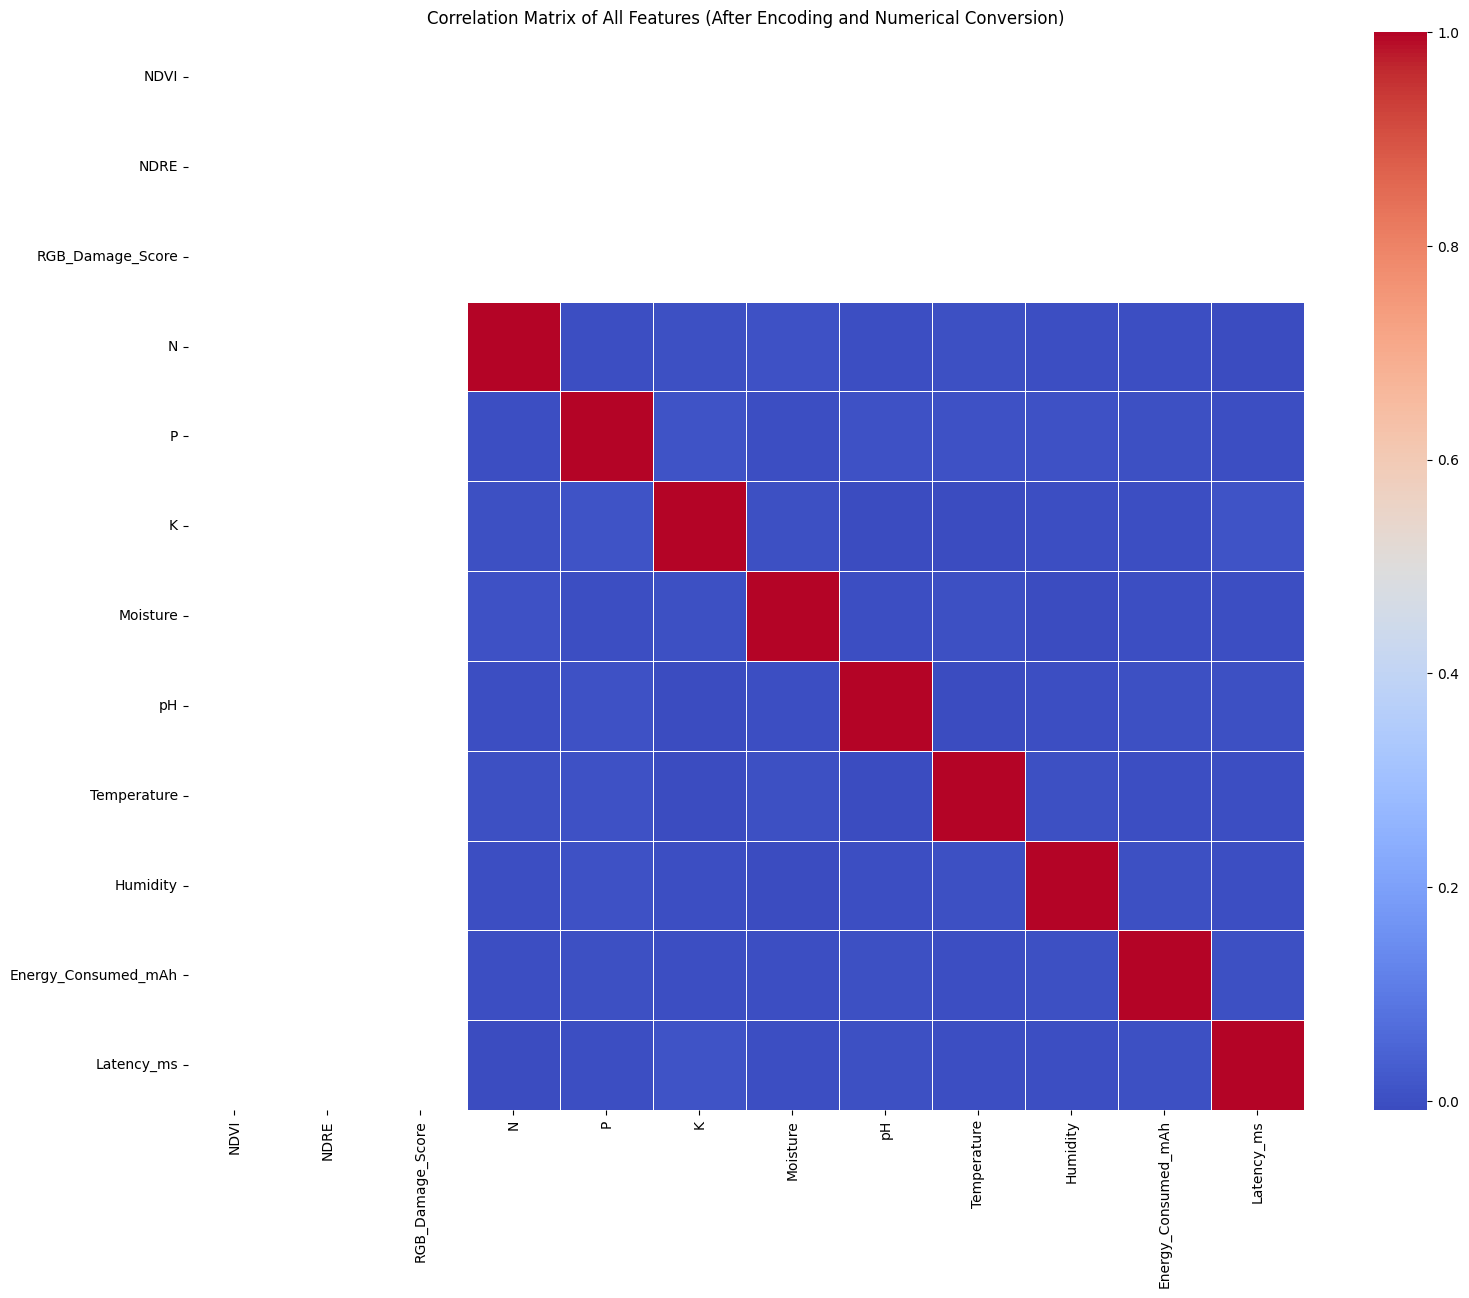


--- 5.2 Variance Threshold ---
Jumlah fitur sebelum Variance Threshold: 12
Jumlah fitur setelah Variance Threshold: 9
Fitur yang dipilih oleh Variance Threshold: ['N', 'P', 'K', 'Moisture', 'pH', 'Temperature', 'Humidity', 'Energy_Consumed_mAh', 'Latency_ms']

--- 5.3 Correlation-based Filtering ---
Jumlah fitur sebelum Correlation-based filtering: 9
Jumlah fitur setelah Correlation-based filtering: 9
Fitur yang dihapus karena korelasi tinggi: []
Fitur yang dipilih oleh Correlation-based filtering: ['N', 'P', 'K', 'Moisture', 'pH', 'Temperature', 'Humidity', 'Energy_Consumed_mAh', 'Latency_ms']

--- 5.4 SelectKBest (dengan target 'Apply Pesticide') ---
Jumlah fitur sebelum SelectKBest: 9
Jumlah fitur setelah SelectKBest (top 9): 9
Fitur yang dipilih oleh SelectKBest: ['N', 'P', 'K', 'Moisture', 'pH', 'Temperature', 'Humidity', 'Energy_Consumed_mAh', 'Latency_ms']

--- Ringkasan Fitur yang Dipilih ---
Total fitur yang dipilih: 9
Daftar fitur akhir yang akan digunakan:
['N', 'P', 'K', '

In [12]:
# Membuat salinan DataFrame hasil normalisasi untuk proses pemilihan fitur
df_for_fs = df_normalized_output.copy()
print("DataFrame hasil normalisasi berhasil disalin untuk pemilihan fitur.")

# --- Persiapan: Konversi Timestamp dan Identifikasi Fitur ---
# Konversi kolom timestamp ke datetime objects. Kolom ini tidak akan digunakan langsung dalam
# pemilihan fitur berbasis statistik, namun penting untuk potensi analisis time-series di EDA.
if 'UAV_Timestamp' in df_for_fs.columns:
    df_for_fs['UAV_Timestamp'] = pd.to_datetime(df_for_fs['UAV_Timestamp'])
    print("Kolom 'UAV_Timestamp' berhasil dikonversi ke datetime.")
if 'Migration_Timestamp' in df_for_fs.columns:
    df_for_fs['Migration_Timestamp'] = pd.to_datetime(df_for_fs['Migration_Timestamp'])
    print("Kolom 'Migration_Timestamp' berhasil dikonversi ke datetime.")

# Memisahkan target variable (jika ada) dan fitur
# 'Action_Suggested' dipilih sebagai target karena relevan dengan rekomendasi untuk dashboard.
target_column = 'Action_Suggested'

if target_column in df_for_fs.columns:
    # Melakukan Label Encoding pada target variable kategorikal
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df_for_fs[target_column] = le.fit_transform(df_for_fs[target_column])
    y = df_for_fs[target_column] # Target variable
    X = df_for_fs.drop(columns=[target_column]) # Features
    print(f"Target variable '{target_column}' berhasil di-encode.")
else:
    print(f"Kolom target '{target_column}' tidak ditemukan. Melakukan pemilihan fitur tanpa target.")
    y = None
    X = df_for_fs.copy()

# Mengidentifikasi fitur numerik dan kategorikal
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Menghapus kolom timestamp dari daftar fitur kategorikal jika masih ada (seharusnya sudah datetime)
for ts_col in ['UAV_Timestamp', 'Migration_Timestamp']:
    if ts_col in categorical_features:
        categorical_features.remove(ts_col)

# Mengidentifikasi dan menghapus kolom ID dengan kardinalitas tinggi yang tidak relevan
# untuk one-hot encoding dan feature selection (misalnya, 'Zone_ID', 'Image_Source_ID')
id_columns_to_exclude = ['Zone_ID', 'Image_Source_ID'] # Ini adalah ID unik, tidak cocok untuk di-encode
categorical_features = [col for col in categorical_features if col not in id_columns_to_exclude]

print(f"\nFitur numerik: {numerical_features}")
print(f"Fitur kategorikal untuk One-Hot Encoding: {categorical_features}")

# Melakukan One-Hot Encoding pada fitur kategorikal yang dipilih
# Menghapus kolom ID yang dikecualikan sebelum encoding
X_encoded = pd.get_dummies(X.drop(columns=id_columns_to_exclude, errors='ignore'),
                           columns=categorical_features, drop_first=True)
print(f"Shape dataset setelah One-Hot Encoding: {X_encoded.shape}")

# Memastikan semua fitur adalah numerik setelah encoding
X_final_features = X_encoded.select_dtypes(include=np.number)
print(f"Jumlah fitur numerik akhir setelah encoding: {X_final_features.shape[1]}")

# --- 5.1 Correlation Matrix Heatmap ---
print("\n--- 5.1 Correlation Matrix Heatmap ---")
# Visualisasi matriks korelasi untuk memahami hubungan antar fitur
plt.figure(figsize=(18, 14))
sns.heatmap(X_final_features.corr(), cmap='coolwarm', annot=False, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Features (After Encoding and Numerical Conversion)')
plt.show()

# --- 5.2 Variance Threshold ---
print("\n--- 5.2 Variance Threshold ---")
# Menghapus fitur dengan variansi sangat rendah, karena fitur tersebut cenderung konstan
# dan tidak memberikan informasi yang signifikan.
# Ambang batas 0.01 digunakan karena data sudah dinormalisasi (Min-Max Scaled).
selector_vt = VarianceThreshold(threshold=0.01)
X_vt = selector_vt.fit_transform(X_final_features)
selected_cols_vt = X_final_features.columns[selector_vt.get_support()]

print(f"Jumlah fitur sebelum Variance Threshold: {X_final_features.shape[1]}")
print(f"Jumlah fitur setelah Variance Threshold: {X_vt.shape[1]}")
print(f"Fitur yang dipilih oleh Variance Threshold: {selected_cols_vt.tolist()}")

# Memperbarui DataFrame fitur untuk langkah selanjutnya
X_final_features = X_final_features[selected_cols_vt]

# --- 5.3 Correlation-based Filtering ---
print("\n--- 5.3 Correlation-based Filtering ---")
# Menghapus fitur yang sangat berkorelasi (misalnya, korelasi absolut > 0.95)
# untuk mengurangi redundansi dan multikolinearitas dalam dataset.
corr_matrix_filtered = X_final_features.corr().abs()
upper_tri = corr_matrix_filtered.where(np.triu(np.ones(corr_matrix_filtered.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

X_corr_filtered = X_final_features.drop(columns=to_drop_corr)

print(f"Jumlah fitur sebelum Correlation-based filtering: {X_final_features.shape[1]}")
print(f"Jumlah fitur setelah Correlation-based filtering: {X_corr_filtered.shape[1]}")
print(f"Fitur yang dihapus karena korelasi tinggi: {to_drop_corr}")
print(f"Fitur yang dipilih oleh Correlation-based filtering: {X_corr_filtered.columns.tolist()}")

# Memperbarui DataFrame fitur untuk langkah selanjutnya
X_final_features = X_corr_filtered

# --- 5.4 SelectKBest (Jika ada target/label) ---
if y is not None:
    print(f"\n--- 5.4 SelectKBest (dengan target '{le.inverse_transform(y)[0]}') ---")
    # Menggunakan SelectKBest dengan f_classif untuk memilih K fitur terbaik
    # yang paling relevan dengan target 'Action_Suggested'.
    # k=10 dipilih sebagai contoh, bisa disesuaikan. Pastikan k tidak melebihi jumlah fitur yang tersedia.
    k_best_features = min(10, X_final_features.shape[1])
    selector_kbest = SelectKBest(score_func=f_classif, k=k_best_features)
    X_kbest = selector_kbest.fit_transform(X_final_features, y)
    selected_cols_kbest = X_final_features.columns[selector_kbest.get_support()]

    print(f"Jumlah fitur sebelum SelectKBest: {X_final_features.shape[1]}")
    print(f"Jumlah fitur setelah SelectKBest (top {k_best_features}): {X_kbest.shape[1]}")
    print(f"Fitur yang dipilih oleh SelectKBest: {selected_cols_kbest.tolist()}")

    X_selected_final = X_final_features[selected_cols_kbest]
else:
    print("\n--- 5.4 SelectKBest (Tidak digunakan karena tidak ada target/label yang didefinisikan) ---")
    X_selected_final = X_final_features.copy()
    print("Fitur yang dipilih adalah hasil dari Variance Threshold dan Correlation-based filtering.")

# --- Ringkasan Fitur yang Dipilih dan Penjelasan ---
print("\n--- Ringkasan Fitur yang Dipilih ---")
print(f"Total fitur yang dipilih: {X_selected_final.shape[1]}")
print("Daftar fitur akhir yang akan digunakan:")
print(X_selected_final.columns.tolist())

# Creating df_selected_final which will be used in subsequent steps (EDA, Output File)
# It should contain the final selected features, the decoded target, and relevant timestamps.
df_selected_final = X_selected_final.copy()

# Add the original target column back to df_selected_final (decoded for readability in EDA)
if y is not None:
    df_selected_final[target_column] = le.inverse_transform(y)
    print(f"Target column '{target_column}' (decoded) added to df_selected_final.")

# Add timestamp columns back. These were already converted to datetime in df_for_fs.
# df_for_fs is essentially df_normalized_output, which retains these non-numerical columns.
for ts_col in ['UAV_Timestamp', 'Migration_Timestamp']:
    if ts_col in df_for_fs.columns:
        df_selected_final[ts_col] = df_for_fs[ts_col]
        print(f"Column '{ts_col}' added back to df_selected_final.")

print("\n--- Penjelasan Alasan Pemilihan Fitur untuk Dashboard IoT Pertanian ---")
print("Pemilihan fitur ini dilakukan melalui serangkaian langkah untuk memastikan fitur yang paling informatif, tidak redundan, dan relevan terpilih:")
print("1.  **Relevansi Statistik (Variance Threshold)**: Fitur dengan variansi yang sangat rendah dihilangkan karena nilai-nilai yang hampir seragam di seluruh dataset tidak memberikan informasi yang cukup untuk membedakan pola atau menginformasikan keputusan pada dashboard. Ini mencegah 'noise' atau fitur yang tidak relevan masuk ke dalam model atau dashboard.")
print("2.  **Mengurangi Redundansi (Correlation-based Filtering)**: Fitur yang sangat berkorelasi satu sama lain dihapus. Multikolinearitas tinggi dapat menyebabkan model menjadi tidak stabil dan sulit diinterpretasikan. Dengan menghilangkan fitur yang redundan, kita mendapatkan dataset yang lebih efisien dan setiap fitur yang tersisa berkontribusi informasi yang unik. Untuk dashboard, ini berarti setiap metrik yang ditampilkan memiliki arti independen.")
if y is not None:
    print("3.  **Relevansi dengan Target (SelectKBest)**: Menggunakan metode SelectKBest dengan fungsi scoring `f_classif`, fitur-fitur dipilih berdasarkan seberapa kuat hubungannya dengan variabel target 'Action_Suggested'. Fitur-fitur ini sangat penting untuk dashboard karena dapat membantu petani memahami faktor-faktor kunci yang memicu rekomendasi tindakan tertentu (misalnya, 'Apply Pesticide', 'Monitor'). Ini memungkinkan dashboard untuk tidak hanya menampilkan data sensor, tetapi juga memberikan wawasan yang dapat ditindaklanjuti.")
print("Dengan demikian, fitur-fitur yang tersisa diharapkan menjadi yang paling informatif, tidak redundan, dan relevan secara prediktif untuk membangun dashboard IoT pertanian yang efisien, mudah diinterpretasi, dan memberikan wawasan yang berharga bagi petani kecil.")

## 6. Visualisasi Awal (EDA)


--- Visualisasi Awal (EDA) ---

Menampilkan Histogram untuk Fitur Numerik...


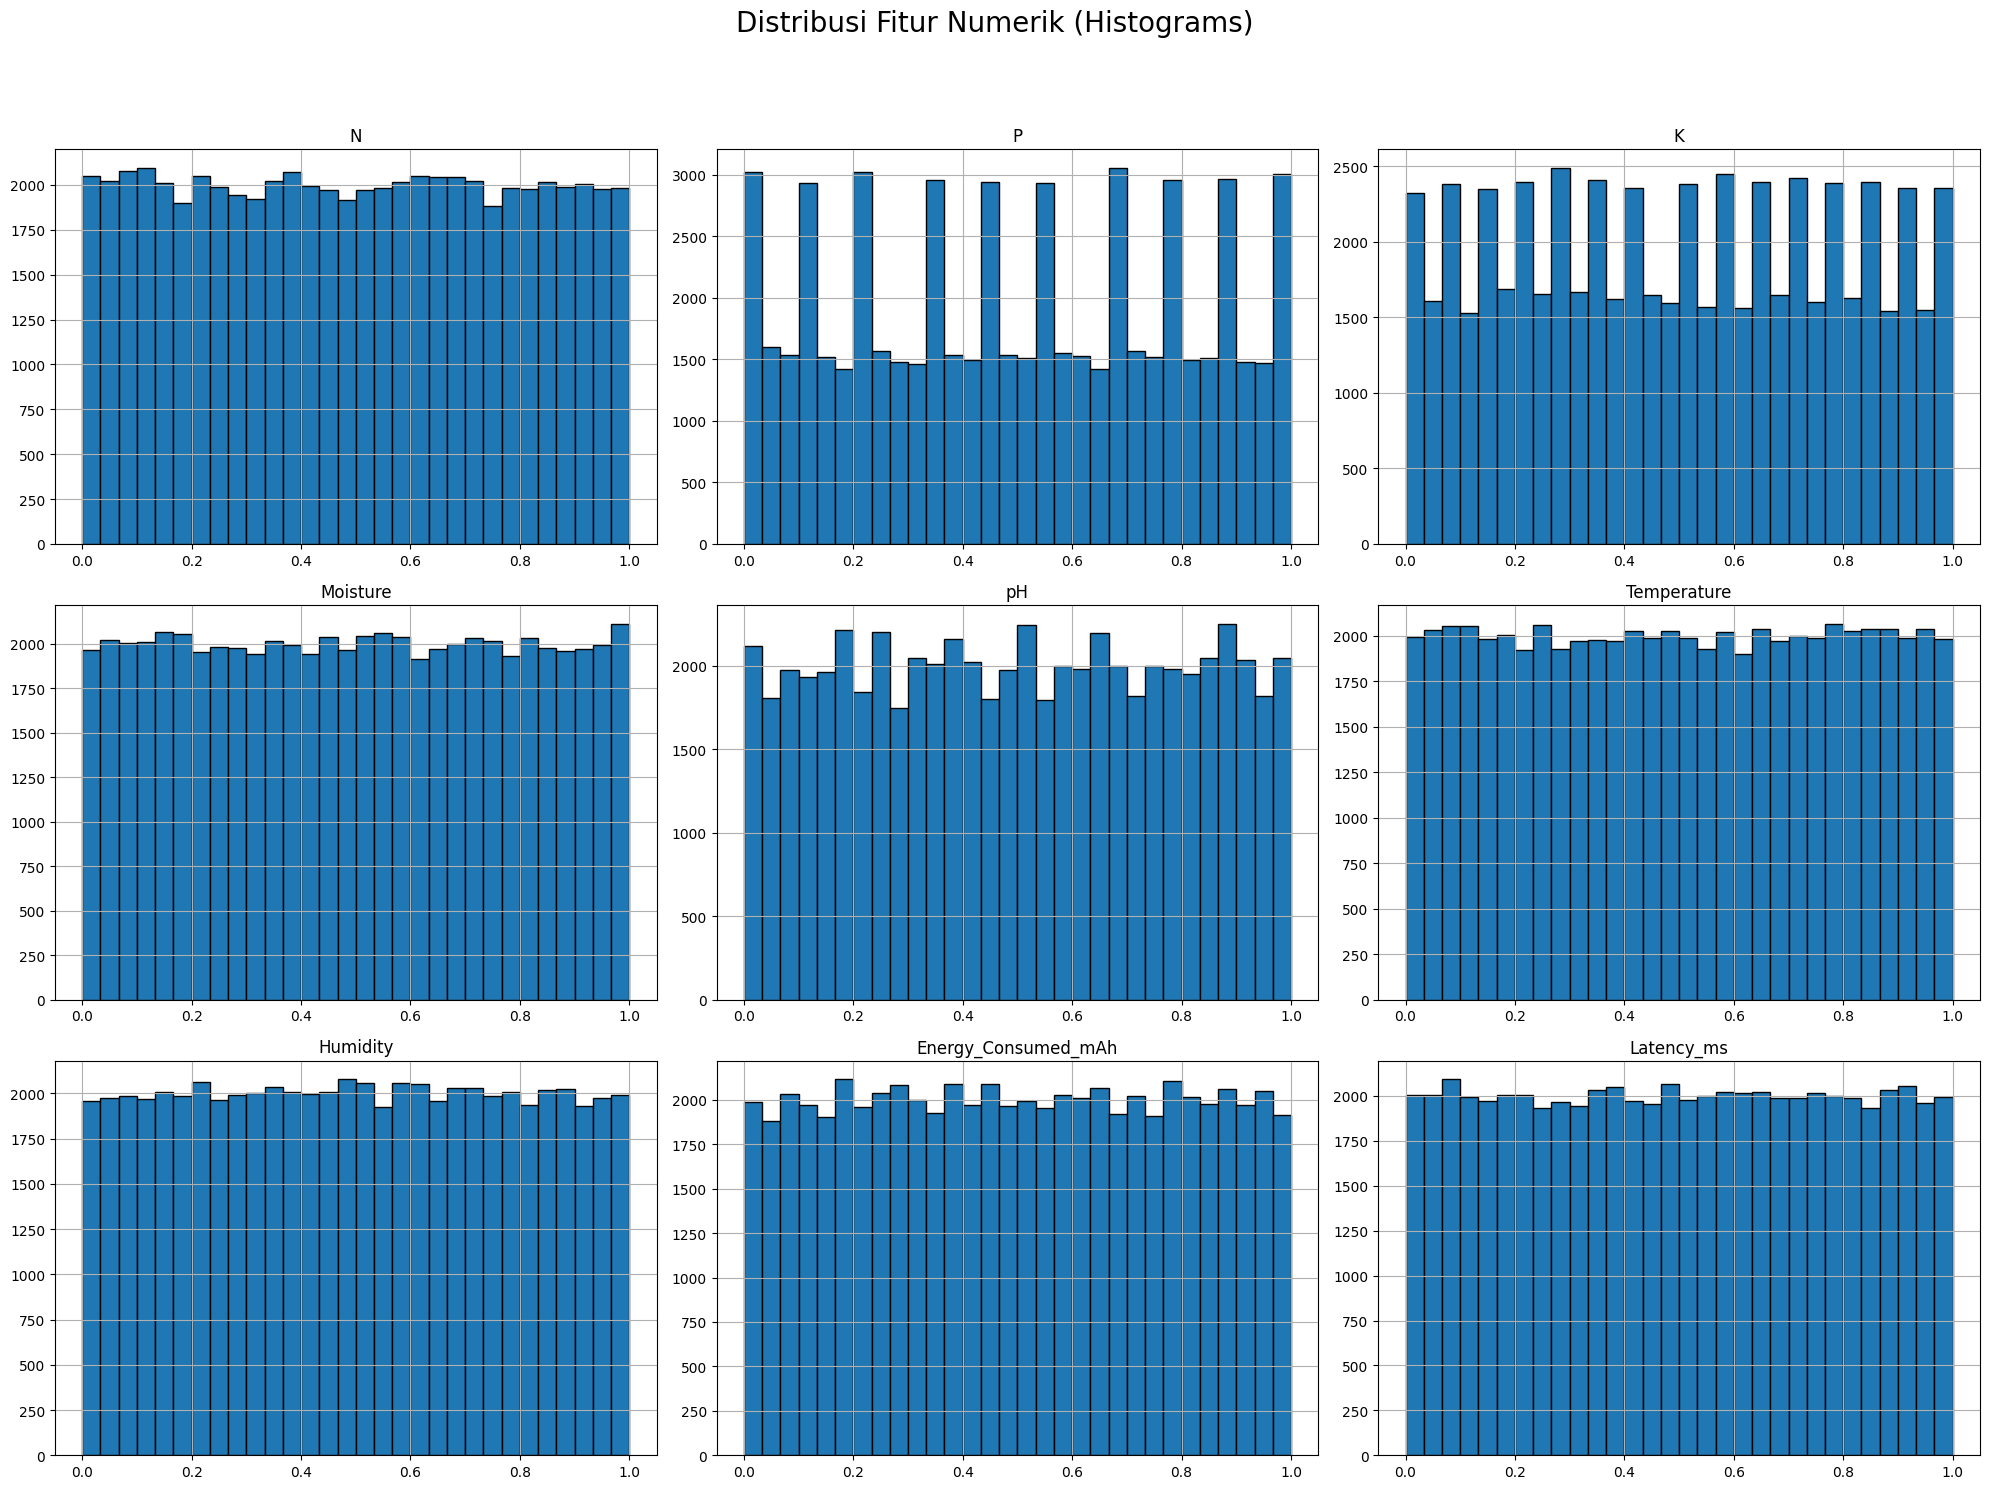

Interpretasi: Histogram menunjukkan distribusi setiap fitur numerik. Kita bisa melihat apakah distribusi cenderung normal, miring (skewed), atau memiliki beberapa mode. Ini membantu memahami karakteristik data dan mendeteksi anomali.

Menampilkan Boxplot untuk Fitur Numerik...


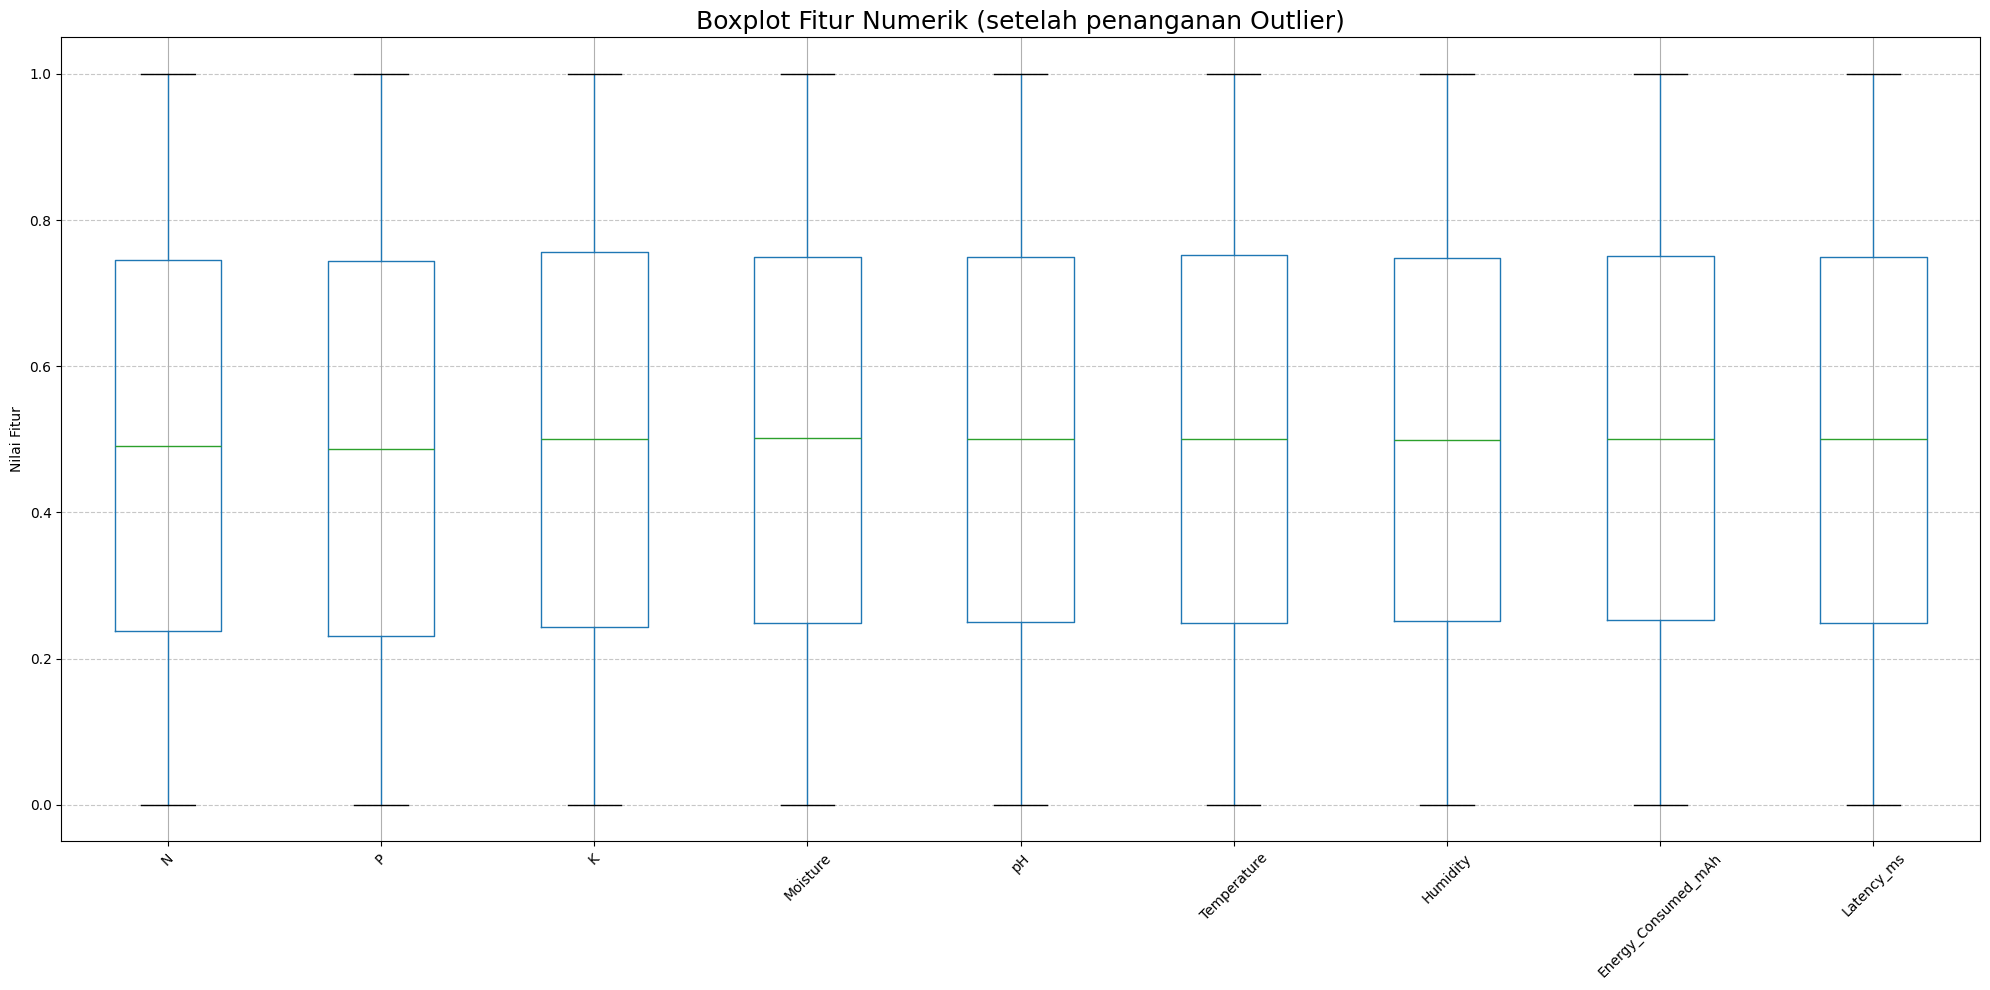

Interpretasi: Boxplot memberikan gambaran ringkas tentang median, kuartil, dan penyebaran data untuk setiap fitur. Meskipun outlier telah ditangani (di-clipping), boxplot masih dapat menunjukkan potensi asimetri atau adanya nilai ekstrem yang mendekati batas IQR.

Menampilkan Heatmap Korelasi Fitur yang Dipilih...


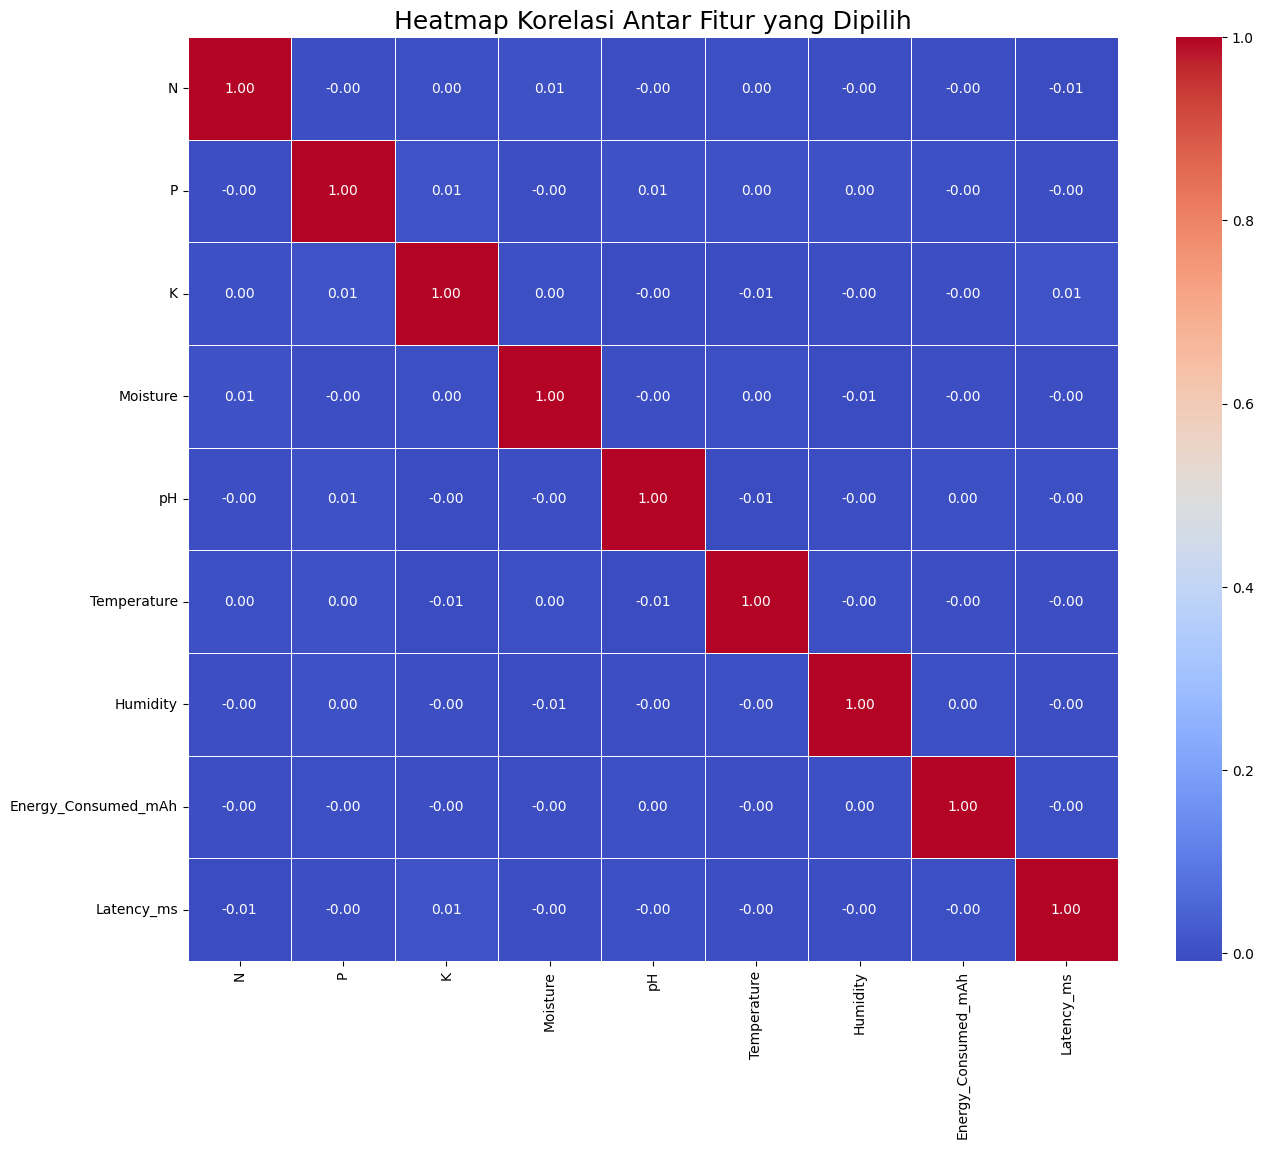

Interpretasi: Heatmap korelasi visual ini menunjukkan hubungan linear antar fitur yang tersisa. Warna yang lebih terang (mendekati 1 atau -1) menunjukkan korelasi yang kuat, sedangkan warna mendekati nol menunjukkan korelasi lemah. Ini membantu memastikan fitur yang dipilih tidak saling tumpang tindih informasinya.

Menampilkan Pairplot (untuk subset fitur jika jumlah fitur > 5)...
Melewatkan Pairplot karena jumlah fitur numerik (9) terlalu banyak. Pairplot mungkin terlalu padat dan membutuhkan waktu lama untuk digambar.
Interpretasi: Untuk dataset dengan banyak fitur, pairplot menjadi tidak praktis. Sebagai gantinya, analisis korelasi dan visualisasi individual lebih efektif.

Menampilkan Time-series plot (jika ada timestamp dan fitur numerik yang relevan)...


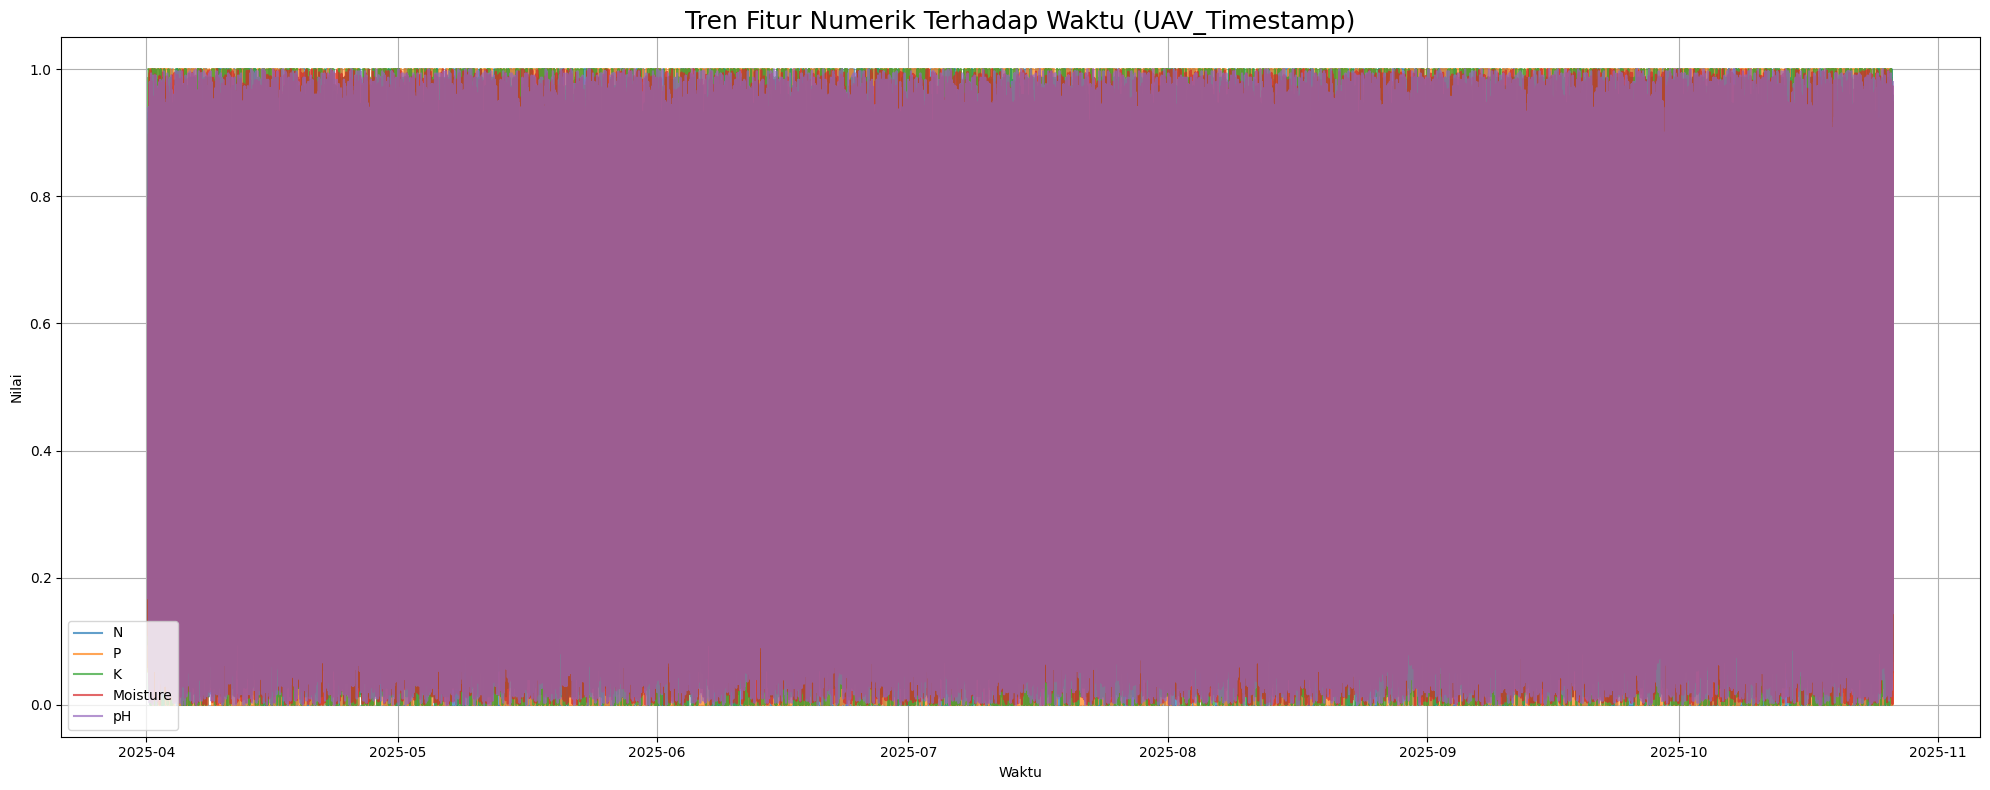

Interpretasi: Plot time-series menunjukkan bagaimana nilai fitur-fitur penting berubah seiring waktu. Ini krusial untuk dashboard pertanian IoT karena perubahan nilai sensor dari waktu ke waktu dapat mengindikasikan tren pertumbuhan tanaman, kondisi lingkungan, atau potensi masalah. Misalnya, penurunan kelembaban atau pH yang berkelanjutan mungkin memerlukan tindakan.

Menampilkan Distribusi Target (jika ada)...


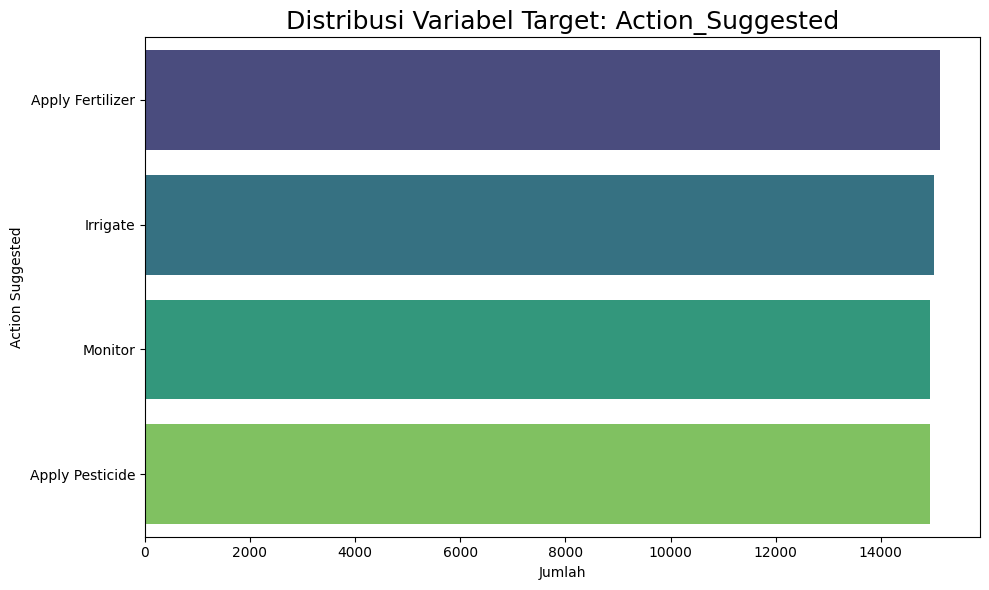

Interpretasi: Visualisasi distribusi variabel target 'Action_Suggested' menunjukkan frekuensi setiap kategori tindakan. Ini membantu memahami sebaran masalah atau rekomendasi yang paling sering muncul, yang penting untuk perancangan fitur di dashboard, seperti prioritas notifikasi atau rekomendasi default.


In [13]:
# Membuat salinan DataFrame untuk visualisasi
df_eda = df_selected_final.copy()

print("\n--- Visualisasi Awal (EDA) ---")

# --- 6.1 Histogram semua fitur numerik ---
print("\nMenampilkan Histogram untuk Fitur Numerik...")
# Pilih hanya kolom numerik untuk histogram
numerical_cols_eda = df_eda.select_dtypes(include=np.number).columns.tolist()

if numerical_cols_eda:
    df_eda[numerical_cols_eda].hist(bins=30, figsize=(20, 15), edgecolor='black')
    plt.suptitle('Distribusi Fitur Numerik (Histograms)', y=1.02, fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()
    print("Interpretasi: Histogram menunjukkan distribusi setiap fitur numerik. Kita bisa melihat apakah distribusi cenderung normal, miring (skewed), atau memiliki beberapa mode. Ini membantu memahami karakteristik data dan mendeteksi anomali.")
else:
    print("Tidak ada fitur numerik yang tersisa untuk divisualisasikan dalam histogram.")

# --- 6.2 Boxplot untuk outlier (setelah clipping, tetap bisa menunjukkan distribusi) ---
print("\nMenampilkan Boxplot untuk Fitur Numerik...")
if numerical_cols_eda:
    plt.figure(figsize=(20, 10))
    df_eda[numerical_cols_eda].boxplot(rot=45)
    plt.title('Boxplot Fitur Numerik (setelah penanganan Outlier)', fontsize=18)
    plt.ylabel('Nilai Fitur')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    print("Interpretasi: Boxplot memberikan gambaran ringkas tentang median, kuartil, dan penyebaran data untuk setiap fitur. Meskipun outlier telah ditangani (di-clipping), boxplot masih dapat menunjukkan potensi asimetri atau adanya nilai ekstrem yang mendekati batas IQR.")
else:
    print("Tidak ada fitur numerik yang tersisa untuk divisualisasikan dalam boxplot.")

# --- 6.3 Heatmap korelasi (fitur yang sudah dipilih) ---
print("\nMenampilkan Heatmap Korelasi Fitur yang Dipilih...")
plt.figure(figsize=(15, 12))
sns.heatmap(df_eda[numerical_cols_eda].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Fitur yang Dipilih', fontsize=18)
plt.show()
print("Interpretasi: Heatmap korelasi visual ini menunjukkan hubungan linear antar fitur yang tersisa. Warna yang lebih terang (mendekati 1 atau -1) menunjukkan korelasi yang kuat, sedangkan warna mendekati nol menunjukkan korelasi lemah. Ini membantu memastikan fitur yang dipilih tidak saling tumpang tindih informasinya.")

# --- 6.4 Pairplot (jika memungkinkan, untuk subset fitur) ---
# Pairplot bisa sangat lambat untuk banyak fitur. Batasi jumlah fitur.
print("\nMenampilkan Pairplot (untuk subset fitur jika jumlah fitur > 5)...")
if len(numerical_cols_eda) > 1 and len(numerical_cols_eda) <= 5: # Batasi untuk fitur yang lebih sedikit
    sns.pairplot(df_eda[numerical_cols_eda])
    plt.suptitle('Pairplot Fitur Numerik (Subset)', y=1.02, fontsize=18)
    plt.show()
    print("Interpretasi: Pairplot menampilkan scatter plot untuk setiap pasangan fitur dan histogram untuk setiap fitur secara individual. Ini sangat berguna untuk menemukan hubungan non-linear dan pola distribusi data yang lebih kompleks antar fitur.")
elif len(numerical_cols_eda) > 5:
    print(f"Melewatkan Pairplot karena jumlah fitur numerik ({len(numerical_cols_eda)}) terlalu banyak. Pairplot mungkin terlalu padat dan membutuhkan waktu lama untuk digambar.")
    print("Interpretasi: Untuk dataset dengan banyak fitur, pairplot menjadi tidak praktis. Sebagai gantinya, analisis korelasi dan visualisasi individual lebih efektif.")
else:
    print("Tidak cukup fitur numerik untuk membuat pairplot.")

# --- 6.5 Time-series plot jika ada timestamp ---
print("\nMenampilkan Time-series plot (jika ada timestamp dan fitur numerik yang relevan)...")

timestamp_cols = ['UAV_Timestamp', 'Migration_Timestamp']
timestamp_present = False
for ts_col in timestamp_cols:
    if ts_col in df_cleaned.columns:
        # Pastikan kolom timestamp sudah dalam format datetime
        df_eda[ts_col] = pd.to_datetime(df_cleaned[ts_col])
        df_eda.set_index(ts_col, inplace=True, drop=False)
        timestamp_present = True
        break # Ambil timestamp pertama yang ditemukan

if timestamp_present and numerical_cols_eda:
    plt.figure(figsize=(20, 8))
    for col in numerical_cols_eda[:5]: # Batasi ke 5 fitur pertama untuk kejelasan
        plt.plot(df_eda.index, df_eda[col], label=col, alpha=0.7)
    plt.title(f'Tren Fitur Numerik Terhadap Waktu ({df_eda.index.name})', fontsize=18)
    plt.xlabel('Waktu')
    plt.ylabel('Nilai')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("Interpretasi: Plot time-series menunjukkan bagaimana nilai fitur-fitur penting berubah seiring waktu. Ini krusial untuk dashboard pertanian IoT karena perubahan nilai sensor dari waktu ke waktu dapat mengindikasikan tren pertumbuhan tanaman, kondisi lingkungan, atau potensi masalah. Misalnya, penurunan kelembaban atau pH yang berkelanjutan mungkin memerlukan tindakan.")
else:
    print("Tidak ada kolom timestamp yang terdeteksi atau tidak ada fitur numerik untuk time-series plot.")

# --- 6.6 Distribusi target (jika ada) ---
print("\nMenampilkan Distribusi Target (jika ada)...")
if 'Action_Suggested' in df_cleaned.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df_cleaned['Action_Suggested'], order=df_cleaned['Action_Suggested'].value_counts().index, palette='viridis')
    plt.title('Distribusi Variabel Target: Action_Suggested', fontsize=18)
    plt.xlabel('Jumlah')
    plt.ylabel('Action Suggested')
    plt.tight_layout()
    plt.show()
    print("Interpretasi: Visualisasi distribusi variabel target 'Action_Suggested' menunjukkan frekuensi setiap kategori tindakan. Ini membantu memahami sebaran masalah atau rekomendasi yang paling sering muncul, yang penting untuk perancangan fitur di dashboard, seperti prioritas notifikasi atau rekomendasi default.")
else:
    print("Variabel target 'Action_Suggested' tidak ditemukan di DataFrame asli untuk visualisasi distribusinya.")

In [17]:
print("\nRingkasan Statistik Deskriptif untuk df_selected_final:")
# Menampilkan statistik deskriptif untuk fitur-fitur numerik yang dipilih
display(df_selected_final.describe())

print("\nInterpretasi: Tabel di atas menyajikan statistik deskriptif kunci untuk setiap fitur numerik di `df_selected_final`. Ini mencakup count (jumlah data non-null), mean (rata-rata), std (deviasi standar), min (nilai minimum), 25% (kuartil pertama), 50% (median/kuartil kedua), 75% (kuartil ketiga), dan max (nilai maksimum). Ini membantu kita memahami sebaran, tendensi sentral, dan rentang nilai dari setiap fitur, serta mendeteksi potensi masalah seperti skewness atau outlier yang masih tersisa.")


Ringkasan Statistik Deskriptif untuk df_selected_final:


,N,P,K,Moisture,pH,Temperature,Humidity,Energy_Consumed_mAh,Latency_ms,UAV_Timestamp,Migration_Timestamp
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000,60000
mean,0.498272,0.499209,0.499182,0.500033,0.500694,0.500427,0.500051,0.500525,0.499787,2025-07-14 09:57:30,2025-09-23 07:25:47.812000512
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2025-04-01 06:00:00,2025-04-01 06:20:00
25%,0.237288,0.230769,0.243243,0.248333,0.250000,0.249167,0.251143,0.252222,0.249333,2025-05-23 07:58:45,2025-10-01 00:05:00
50%,0.491525,0.487179,0.500000,0.501333,0.500000,0.500000,0.499571,0.500000,0.499833,2025-07-14 09:57:30,2025-10-01 00:05:00
75%,0.745763,0.743590,0.756757,0.750000,0.750000,0.752500,0.748143,0.751111,0.749556,2025-09-04 11:56:15,2025-10-01 00:05:00
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2025-10-26 13:55:00,2025-10-26 13:45:00
std,0.294151,0.296166,0.291144,0.289065,0.288591,0.289455,0.287565,0.287959,0.288875,NaN,NaN



Interpretasi: Tabel di atas menyajikan statistik deskriptif kunci untuk setiap fitur numerik di `df_selected_final`. Ini mencakup count (jumlah data non-null), mean (rata-rata), std (deviasi standar), min (nilai minimum), 25% (kuartil pertama), 50% (median/kuartil kedua), 75% (kuartil ketiga), dan max (nilai maksimum). Ini membantu kita memahami sebaran, tendensi sentral, dan rentang nilai dari setiap fitur, serta mendeteksi potensi masalah seperti skewness atau outlier yang masih tersisa.



Menampilkan Time-series plot (jika ada timestamp dan fitur numerik yang relevan)...


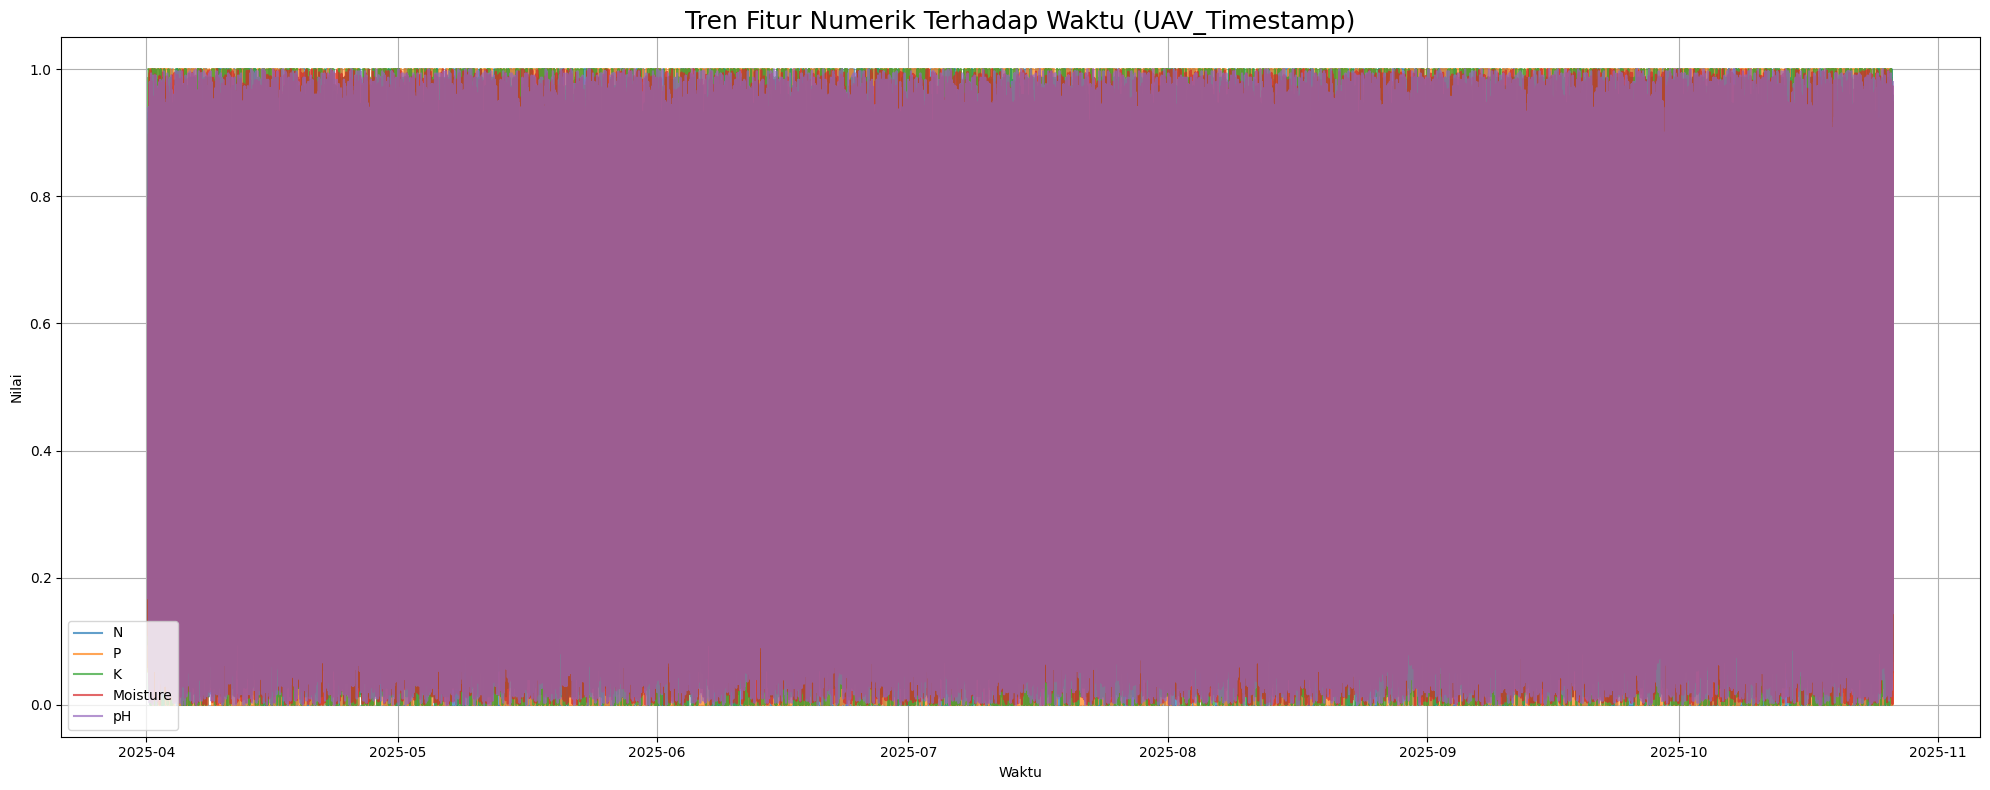

Interpretasi: Plot time-series menunjukkan bagaimana nilai fitur-fitur penting berubah seiring waktu. Ini krusial untuk dashboard pertanian IoT karena perubahan nilai sensor dari waktu ke waktu dapat mengindikasikan tren pertumbuhan tanaman, kondisi lingkungan, atau potensi masalah. Misalnya, penurunan kelembaban atau pH yang berkelanjutan mungkin memerlukan tindakan.


In [14]:
print("\nMenampilkan Time-series plot (jika ada timestamp dan fitur numerik yang relevan)...")

timestamp_cols = ['UAV_Timestamp', 'Migration_Timestamp']

# Ensure df_eda has UAV_Timestamp as index and is datetime type
# This part assumes df_eda has been created correctly from df_selected_final
# and 'UAV_Timestamp' is present in df_eda.
# If not, ensure it's converted and set as index here.
if 'UAV_Timestamp' in df_eda.columns and not isinstance(df_eda.index, pd.DatetimeIndex):
    df_eda['UAV_Timestamp'] = pd.to_datetime(df_eda['UAV_Timestamp'])
    df_eda.set_index('UAV_Timestamp', inplace=True, drop=False)

numerical_cols_eda = df_eda.select_dtypes(include=np.number).columns.tolist()

if 'UAV_Timestamp' in df_eda.index.name and numerical_cols_eda:
    plt.figure(figsize=(20, 8))
    # Limit to first 5 numerical features for clarity in time-series plot
    for col in numerical_cols_eda[:5]:
        plt.plot(df_eda.index, df_eda[col], label=col, alpha=0.7)
    plt.title(f'Tren Fitur Numerik Terhadap Waktu ({df_eda.index.name})', fontsize=18)
    plt.xlabel('Waktu')
    plt.ylabel('Nilai')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("Interpretasi: Plot time-series menunjukkan bagaimana nilai fitur-fitur penting berubah seiring waktu. Ini krusial untuk dashboard pertanian IoT karena perubahan nilai sensor dari waktu ke waktu dapat mengindikasikan tren pertumbuhan tanaman, kondisi lingkungan, atau potensi masalah. Misalnya, penurunan kelembaban atau pH yang berkelanjutan mungkin memerlukan tindakan.")
else:
    print("Tidak ada kolom timestamp yang terdeteksi atau tidak ada fitur numerik yang relevan untuk time-series plot.")


Menampilkan Distribusi Target (jika ada)...


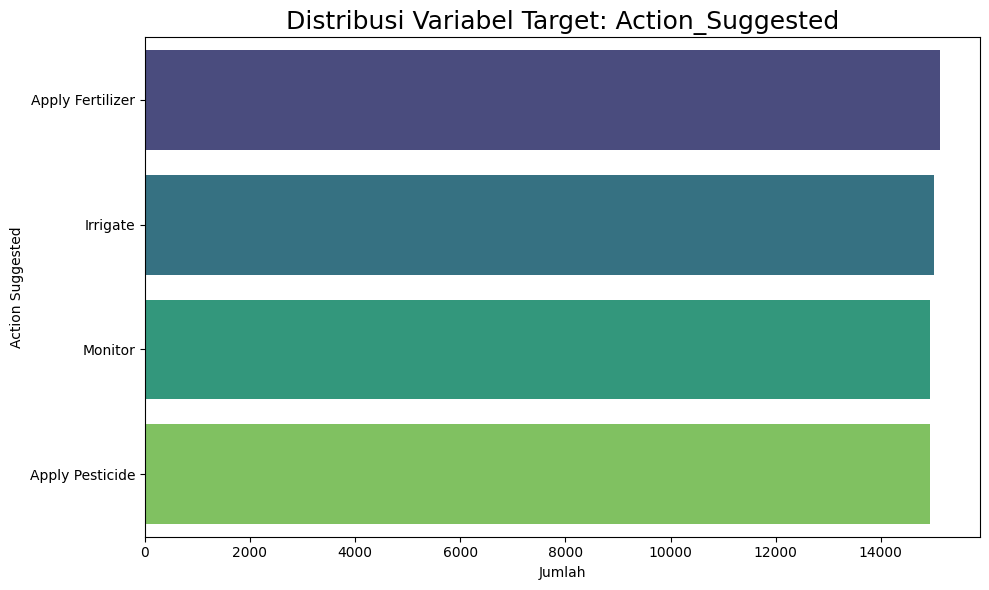

Interpretasi: Visualisasi distribusi variabel target 'Action_Suggested' menunjukkan frekuensi setiap kategori tindakan. Ini membantu memahami sebaran masalah atau rekomendasi yang paling sering muncul, yang penting untuk perancangan fitur di dashboard, seperti prioritas notifikasi atau rekomendasi default.


In [15]:
print("\nMenampilkan Distribusi Target (jika ada)...")
# Use df_selected_final for the target distribution since it has the decoded 'Action_Suggested'
if 'Action_Suggested' in df_selected_final.columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df_selected_final['Action_Suggested'], order=df_selected_final['Action_Suggested'].value_counts().index, palette='viridis')
    plt.title('Distribusi Variabel Target: Action_Suggested', fontsize=18)
    plt.xlabel('Jumlah')
    plt.ylabel('Action Suggested')
    plt.tight_layout()
    plt.show()
    print("Interpretasi: Visualisasi distribusi variabel target 'Action_Suggested' menunjukkan frekuensi setiap kategori tindakan. Ini membantu memahami sebaran masalah atau rekomendasi yang paling sering muncul, yang penting untuk perancangan fitur di dashboard, seperti prioritas notifikasi atau rekomendasi default.")
else:
    print("Variabel target 'Action_Suggested' tidak ditemukan di DataFrame akhir untuk visualisasi distribusinya.")

## 7. Output File

In [16]:
# Menentukan path untuk menyimpan file CSV di Google Drive
output_file_path = '/content/drive/MyDrive/dataset/Agriculture_Preprocessed_for_Dashboard.csv'

try:
    # Menyimpan df_selected_final ke file CSV
    df_selected_final.to_csv(output_file_path, index=False)
    print(f"Data yang telah diproses berhasil disimpan ke: {output_file_path}")

    # Menampilkan 5 baris pertama dari file yang disimpan untuk verifikasi
    print("\nVerifikasi: 5 baris pertama dari file yang disimpan:")
    df_verify = pd.read_csv(output_file_path)
    display(df_verify.head())

    print("\nPenjelasan: File CSV ini berisi dataset pertanian yang telah melalui langkah-langkah preprocessing (pembersihan, normalisasi, dan pemilihan fitur). Dataset ini siap digunakan untuk membangun dashboard IoT atau untuk analisis lebih lanjut. Kolom-kolom yang tersisa adalah fitur-fitur yang paling relevan dan informatif, bersama dengan variabel target 'Action_Suggested' dan timestamp yang diperlukan untuk analisis time-series di dashboard.")

except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan atau memverifikasi file: {e}")

Data yang telah diproses berhasil disimpan ke: /content/drive/MyDrive/dataset/Agriculture_Preprocessed_for_Dashboard.csv

Verifikasi: 5 baris pertama dari file yang disimpan:


,N,P,K,Moisture,pH,Temperature,Humidity,Energy_Consumed_mAh,Latency_ms,Action_Suggested,UAV_Timestamp,Migration_Timestamp
0,0.474576,0.717949,1.000000,0.059667,0.810000,0.531250,0.242429,0.322222,0.287778,Apply Pesticide,2025-04-01 06:00:00,2025-10-01 00:05:00
1,0.847458,0.564103,0.256757,0.137667,0.166667,0.417500,0.437857,0.020000,0.267778,Monitor,2025-04-01 06:05:00,2025-10-01 00:05:00
2,0.237288,0.897436,0.608108,0.109333,0.940000,0.477500,0.439000,0.221111,0.261667,Apply Fertilizer,2025-04-01 06:10:00,2025-10-01 00:05:00
3,0.542373,0.820513,0.675676,0.782667,0.293333,0.635417,0.984857,0.873333,0.274889,Apply Fertilizer,2025-04-01 06:15:00,2025-10-01 00:05:00
4,0.881356,0.589744,0.216216,0.625000,0.333333,0.465417,0.159857,0.021111,0.275333,Apply Fertilizer,2025-04-01 06:20:00,2025-04-01 06:20:00



Penjelasan: File CSV ini berisi dataset pertanian yang telah melalui langkah-langkah preprocessing (pembersihan, normalisasi, dan pemilihan fitur). Dataset ini siap digunakan untuk membangun dashboard IoT atau untuk analisis lebih lanjut. Kolom-kolom yang tersisa adalah fitur-fitur yang paling relevan dan informatif, bersama dengan variabel target 'Action_Suggested' dan timestamp yang diperlukan untuk analisis time-series di dashboard.
